# Trajectory trace: observations, actions, rewards + credit / reward-prediction

Loads a saved **evaluation** trajectory + its checkpoint and reconstructs the actor-weighting signals
from the objective, mirroring the current `compute_a2c_loss` in
`train_treadmill_agent_jax_reward_gated_logits.py`:

- `r_pred` = the reward net's readout of the **actor hidden state** (`predict_reward(actor_hidden)[:, 0]`),
  trained to predict the reward `r_t` at the current step (which `actor_hidden[t]` has not observed yet);
- credit eligibility = low-pass of `feat_t ⊗ action_t` with `feat = [o_t, r_{t-1}]` (widened over the
  last `N_OBS_TIMESTEPS` steps);
- like-for-like RPE `signal = r_t − max(r_pred, 0)`; on a reward the credit is **snapped** to
  `elig · signal`, otherwise it decays; the read-out is `feat_t · credit[:, a]`;
- advantage = `(credit + 1) · nearest_future_reward(r, DELAY_DECAY)`.

In [1]:
import os
# CPU-only analysis. Force CPU BEFORE importing jax so it never touches the (here, nearly-full) GPU.
# If you edit a .py or hit a GPU OOM / a stale-signature TypeError, RESTART THE KERNEL: these env vars
# only apply before jax initializes, and Python won't pick up edited module signatures until re-import.
os.environ['JAX_PLATFORMS'] = 'cpu'          # canonical backend selector (hard-set, not setdefault)
os.environ['JAX_PLATFORM_NAME'] = 'cpu'      # legacy alias
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'

import sys
sys.path.insert(0, os.path.abspath('..'))          # code/
sys.path.insert(0, os.path.abspath('../scripts'))  # training script module

import pickle
import numpy as np
import jax, jax.numpy as jnp
import matplotlib.pyplot as plt
from flax.training import checkpoints

import train_treadmill_agent_jax_reward_gated_logits as M  # note: this import forces matplotlib 'Agg'
from agents.a2c_rnn_reward_pred_flax import A2CRNNFlax, init_network_and_params
from environments.components.treadmill_trajectory import TrajectoryData

# M forces the non-interactive 'Agg' backend on import; restore inline so figures render in the notebook
%matplotlib inline

## Model / trajectory

Point these at the run of interest. Dims must match the run's `TrainingConfig`.

In [2]:
REPO = os.path.abspath('../..')
EXP  = 'persistence_gated_exp_gru_initial_prob_offset_full_pred_r_hidden_v2'

# Evaluation outputs (from evaluate_a2c_jax): a summary pkl and a list of per-episode trajectories.
EVAL_RESULTS_PATH = f'{REPO}/results/{EXP}/evaluation_results_20260813_140348.pkl'
TRAJ_PATH         = f'{REPO}/results/{EXP}/trajectories_20260813_140348.pkl'
CKPT_DIR  = f'{REPO}/checkpoints/{EXP}'   # best checkpoint (saved at step 0)
CKPT_STEP = 0
TRAJ_IDX  = 0                             # which eval episode to trace

# dims from the run's TrainingConfig (asserted against the trajectory below)
OBS, ACT, HID, RNN, UNIT_NOISE = 4, 2, 64, 'GRU', 0.01
WINDOW_DIM = M.RPE_K * (OBS + 1) + ACT + 1   # reward-net init window (the readout is on the hidden state)

In [3]:
# restore weights (into a param-tree target so it deserializes on CPU)
_, params0 = init_network_and_params(HID, ACT, OBS, RNN, 0.0, jax.random.key(0),
                                     reward_pred_hidden_size=M.REWARD_PRED_HIDDEN,
                                     window_dim=WINDOW_DIM, reward_pred_horizon=M.RPE_H + 1)
ckpt_file = f'{CKPT_DIR}/checkpoint_{CKPT_STEP}'
assert os.path.exists(ckpt_file), f'no checkpoint at {ckpt_file} -- restore would return untrained params'
params = checkpoints.restore_checkpoint(ckpt_dir=CKPT_DIR, target={'params': params0}, step=CKPT_STEP)['params']
# sanity: restore_checkpoint SILENTLY returns the untrained target if the step is missing. Confirm
# the restored weights actually differ from the fresh init (diff == 0 would mean the restore was a no-op).
rp_diff = float(jnp.abs(params['params']['reward_pred_readout']['kernel']
                        - params0['params']['reward_pred_readout']['kernel']).max())
print(f'restored checkpoint_{CKPT_STEP}: reward_pred_readout max|w - w_init| = {rp_diff:.4g}  (0 => restore no-op/untrained)')

# eval trajectories: list of per-episode trajectory dicts (full TrajectoryData fields incl. actor_hidden)
with open(TRAJ_PATH, 'rb') as f:
    trajectories = pickle.load(f)
traj_dict = trajectories[TRAJ_IDX]
T = np.asarray(traj_dict['rewards']).shape[0]
assert np.asarray(traj_dict['observations']).shape[1] == OBS + ACT + 1, 'OBS/ACT mismatch vs trajectory'
assert np.asarray(traj_dict['actor_hidden']).shape[1] == HID, 'HID mismatch vs trajectory'
print(f'{len(trajectories)} eval episodes; tracing episode {TRAJ_IDX}, length T = {T}')

# eval summary (best-effort; the pickled config class lives in the training module)
try:
    import __main__ as _main
    for _n in ('TrainingConfig', 'RewardParamStyle', 'RewardFuncType'):
        setattr(_main, _n, getattr(M, _n))
    with open(EVAL_RESULTS_PATH, 'rb') as f:
        eval_results = pickle.load(f)
    print('eval mean reward rate: %.4f +/- %.4f'
          % (eval_results['mean_reward_rate'], eval_results['std_reward_rate']))
except Exception as _e:
    eval_results = None
    print('could not load eval_results summary:', _e)

restored checkpoint_0: reward_pred_readout max|w - w_init| = 0.09948  (0 => restore no-op/untrained)
30 eval episodes; tracing episode 0, length T = 20000
eval mean reward rate: 0.0208 +/- 0.0031


## Compute the signals for this trajectory

During training these come straight out of `compute_a2c_loss` (they're in `metrics`). For a saved
trajectory we recompute them from the checkpoint weights + the saved `actor_hidden`, mirroring the
current code: `r_pred = predict_reward(actor_hidden)[:, 0]` (predicts `r_t`), eligibility is a low-pass
of `feat_t ⊗ a_t` with `feat = [o_t, r_{t-1}]` (widened over the last `N_OBS_TIMESTEPS` steps), the
credit signal is the like-for-like RPE `r_t − max(r_pred, 0)`, credit is **snapped** to `elig·signal`
on a reward step and decays otherwise, and the advantage is `(credit + 1)·nearest_future_reward`.
Credit filters start at zero (as at the start of a session).

In [4]:
A = ACT
obs_full = np.asarray(traj_dict['observations'])            # (T, obs+act+1)
obs      = obs_full[:, :OBS]                                # (T, obs) sensory part (trace panel)
actions  = np.asarray(traj_dict['actions'])
rewards  = np.asarray(traj_dict['rewards'])
actor_hidden = np.asarray(traj_dict['actor_hidden'])       # (T, HID)

# --- r_pred: reward-net readout of the actor hidden state; lag-0 column = predicted r_t ---
rnet = A2CRNNFlax(action_size=A, hidden_size=HID, unit_noise_std=0.0, rnn_type=RNN,
                  obs_size=OBS, reward_pred_hidden_size=M.REWARD_PRED_HIDDEN,
                  reward_pred_horizon=M.RPE_H + 1)
r_hat  = np.asarray(rnet.apply(params, jnp.asarray(actor_hidden), method=A2CRNNFlax.predict_reward))  # (T, RPE_H+1)
r_pred = r_hat[:, 0]                        # (T,) predicted r_t
r_pred_relu = np.maximum(r_pred, 0.0)       # relu'd prediction baseline in the credit signal
rpe_relu    = rewards - r_pred_relu         # like-for-like RPE: r_t - max(r_pred, 0)  (the credit signal)

# --- credit features: [o_t, r_{t-1}], widened over the last N_OBS_TIMESTEPS steps (mirrors _stack_window) ---
feat1 = np.concatenate([obs, obs_full[:, OBS + A:]], axis=1)   # (T, obs+1) = [o_t, prev_reward]
FEAT  = OBS + 1
W     = M.N_OBS_TIMESTEPS
cols  = [feat1 if k == 0 else np.concatenate([np.zeros((k, FEAT)), feat1[:T - k]], axis=0)
         for k in range(W)]                                    # cols[k] = feat shifted back k steps
feat  = np.concatenate(cols[::-1], axis=1)                     # (T, W*FEAT)  oldest .. newest
window_dim = W * FEAT

# --- credit_scan mirror (persistent filters start at zero, as at the start of a session) ---
CE, CDR = M.CREDIT_ELIG_DECAY, M.CREDIT_DECAY_REWARD
eye = np.eye(A)
elig       = np.zeros((window_dim, A))
credit_rew = np.zeros((window_dim, A))
credit_by_action  = np.zeros((T, A))     # feat_t . credit[:, a]  for each action (plot)
credit_for_action = np.zeros(T)          # readout under the action actually taken
for tt in range(T):
    ft = feat[tt]; at = eye[actions[tt]]; r = rewards[tt]; p = r_pred[tt]
    elig = CE * elig + (1 - CE) * (ft[:, None] * at[None, :] / np.sqrt(window_dim * A))
    signal = r - max(p, 0.0)                                   # like-for-like RPE
    credit_rew = elig * signal if r > 0.0 else CDR * credit_rew  # snap on reward, else decay
    credit_by_action[tt]  = ft @ credit_rew                   # (A,)
    credit_for_action[tt] = credit_by_action[tt, actions[tt]]

# --- advantage: (credit + 1) * nearest_future_reward(r, DELAY_DECAY) ---
nfr = np.asarray(M.nearest_future_reward(jnp.asarray(rewards), M.DELAY_DECAY))  # DELAY_DECAY^(k-t)*r_k, nearest k>=t
advantage = (credit_for_action + 1.0) * nfr

print('r_pred [%.4f, %.4f] | credit_by_action [%.4f, %.4f] | advantage [%.4f, %.4f]'
      % (r_pred.min(), r_pred.max(), credit_by_action.min(), credit_by_action.max(),
         advantage.min(), advantage.max()))

r_pred [-0.1145, 0.1668] | credit_by_action [0.0000, 0.4210] | advantage [0.0000, 1.4210]


## Trace

Set `T0`/`T1` to the time window to view (the full trajectory is usually too long to read at once).

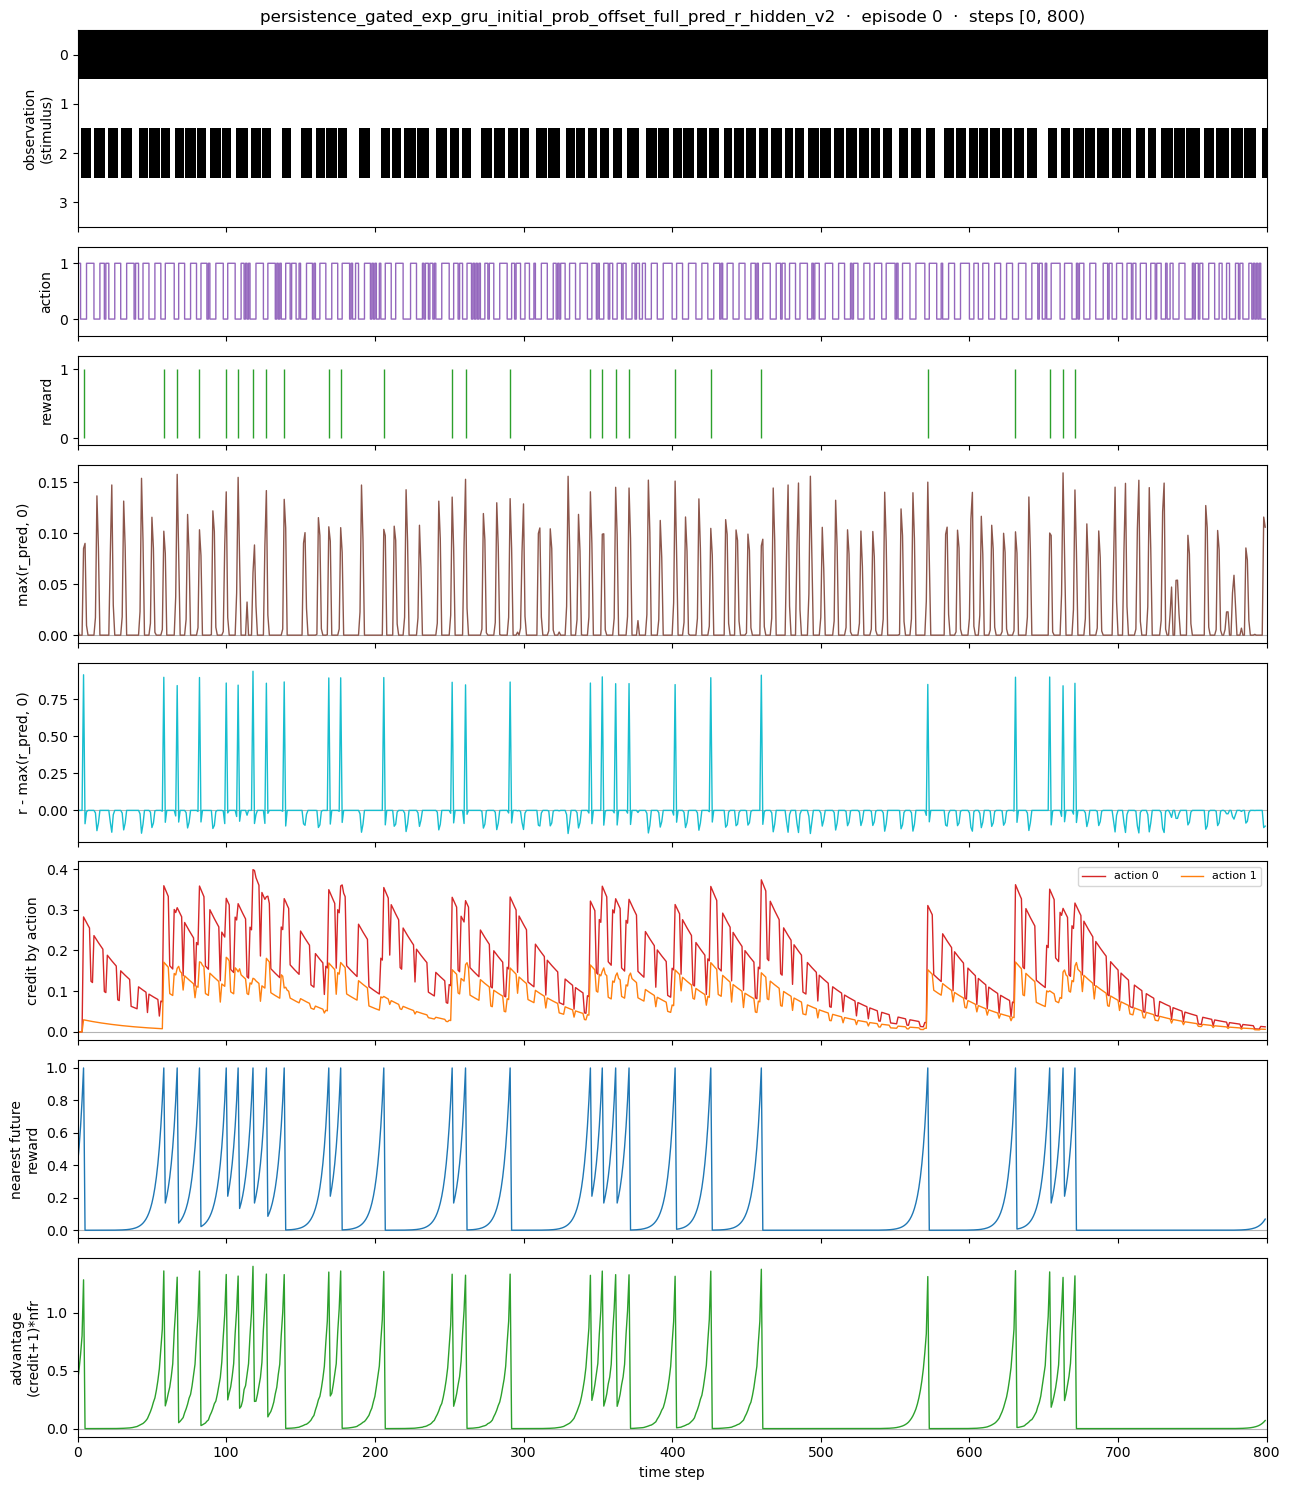

In [ ]:
T0, T1 = 0, min(800, T)          # time window to plot
t = np.arange(T0, T1)

fig, ax = plt.subplots(8, 1, sharex=True, figsize=(13, 15),
                       gridspec_kw={'height_ratios': [1.1, 0.5, 0.5, 1.0, 1.0, 1.0, 1.0, 1.0]})

# 1) observations (stimulus x time)
ax[0].imshow(obs[T0:T1].T, aspect='auto', cmap='Greys', vmin=0, vmax=1,
             extent=[T0, T1, OBS - 0.5, -0.5], interpolation='nearest')
ax[0].set_yticks(range(OBS)); ax[0].set_ylabel('observation\n(stimulus)')

# 2) actions
ax[1].step(t, actions[T0:T1], where='post', color='tab:purple', lw=1)
ax[1].set_yticks([0, 1]); ax[1].set_ylim(-0.3, 1.3); ax[1].set_ylabel('action')

# 3) reward (spikes)
rt = t[rewards[T0:T1] > 0]
ax[2].vlines(rt, 0, 1, color='tab:green', lw=1)
ax[2].set_yticks([0, 1]); ax[2].set_ylim(-0.1, 1.2); ax[2].set_ylabel('reward')

# 4) relu'd reward prediction (baseline in the credit signal)
ax[3].axhline(0, color='0.7', lw=0.8)
ax[3].plot(t, r_pred_relu[T0:T1], color='tab:brown', lw=1)
ax[3].set_ylabel('max(r_pred, 0)')

# 5) r - max(r_pred, 0)  (like-for-like RPE = credit signal)
ax[4].axhline(0, color='0.7', lw=0.8)
ax[4].plot(t, rpe_relu[T0:T1], color='tab:cyan', lw=1)
ax[4].set_ylabel('r - max(r_pred, 0)')

# 6) credit of the current feature under each action, as two lines
ax[5].axhline(0, color='0.7', lw=0.8)
ax[5].plot(t, credit_by_action[T0:T1, 0], color='tab:red', lw=1, label='action 0')
ax[5].plot(t, credit_by_action[T0:T1, 1], color='tab:orange', lw=1, label='action 1')
ax[5].legend(loc='upper right', fontsize=8, ncol=2)
ax[5].set_ylabel('credit by action')

# 7) nearest future reward: DELAY_DECAY^(k-t) * r_k  (advantage multiplier)
ax[6].axhline(0, color='0.7', lw=0.8)
ax[6].plot(t, nfr[T0:T1], color='tab:blue', lw=1)
ax[6].set_ylabel('nearest future\nreward')

# 8) advantage = (credit + 1) * nearest_future_reward
ax[7].axhline(0, color='0.7', lw=0.8)
ax[7].plot(t, advantage[T0:T1], color='tab:green', lw=1)
ax[7].set_ylabel('advantage\n(credit+1)*nfr'); ax[7].set_xlabel('time step')

ax[0].set_title(f'{EXP}  ·  episode {TRAJ_IDX}  ·  steps [{T0}, {T1})')
plt.tight_layout()
plt.show()